In [1]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

Set BCH-specific variables.

In [2]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                #             'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                # 'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                #   'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                #     'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                #     'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                #     'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                #     'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                #     'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                #     'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                    ]


#Continuous predictors.
continuous_predictors = [
    'age_in_days', 'miles_travelled', 'sdi_score',
    'raw_triage_hr', 'raw_triage_rr', 'raw_triage_sp_o2', 'raw_triage_pain', 'raw_triage_sbp', 
    'raw_triage_dbp',
     'crowdedness',  'raw_weight' #Leave out pseudo-nedocs
    
]


#First, define the reference categories.
reference_categories = [
    "Non-Hispanic White", #race
    "M", #sex
    "Walk in", #ed arrival mode
    "English", #language
    "Private", #insurance
    "MA", #home state
    "2019", #year of arrival
    "autumn", #season
    "afternoon", #time of day,
    "unknown" #triage acuity
]
#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}




---LOAD FILES---

#Load in the pre-processed BCH data: pre-epic, with processed chief complaints and raw triage vitals (defined as the first set of vitals at which any vitals are taken).

In [213]:
#Load data.
visits = pd.read_csv(load_filepath + raw_file_name + ".csv", index_col=0, low_memory=False)


#Keep CSNs and then legal predictors.
visits = visits[['csn', 'mrn', 'is_admitted', 'minutes_since_first_arrival'] + pre_binarised_predictors + categorical_predictors + continuous_predictors]

#Save this.
visits.to_csv(save_filepath + 'intermediate-files/visits.csv')

Identify markers of decompensation. We are interested in decompensation that occurs after the first hour.

In [3]:
#Load in vitals across the stay.
vitals = pd.read_csv(load_filepath + "intermediate-files/vitals-with-age-and-pain.csv", index_col=0, engine='pyarrow').rename(columns={
    'time_since_arrival':'timestamp',
    'measure': 'vital_type',
    'value':'vital_value'
})[['csn', 'arrival_time', 'vital_type', 'vital_value', 'age_in_days', 'timestamp']]
print("loaded vitals")


#Load in visits.
visits = pd.read_csv(save_filepath+'intermediate-files/visits.csv', index_col=0, engine='pyarrow')
print("loaded visits")

#Keep only vitals for included visits.
vitals = vitals.merge(visits[['csn']], on='csn', how='inner')

#Transform vitals to numeric.
vitals['vital_value'] = pd.to_numeric(vitals['vital_value'])

#Label outcomes of interest.
# OUTCOME 1: Tachycardia definitions according to the ACLS:
vitals['tachycardia'] = ((vitals['vital_type']=='hr') & (
    ((vitals['age_in_days'] <= 120) & (vitals['vital_value'] >= 205)) | #Less than 4 months old, HR > 205 bpm
    ((vitals['age_in_days'] > 120) & (vitals['age_in_days'] <= 365.25*2) & (vitals['vital_value'] >= 190)) | #4 months to 2 years, HR > 190 bpm 
    ((vitals['age_in_days'] > 365.25*2) & (vitals['age_in_days'] <= 365.25*10) & (vitals['vital_value'] >= 140)) | #2-10 years, HR > 140 bpm
    ((vitals['age_in_days'] > 365.25*10) & (vitals['vital_value'] >= 100)))).astype(int) #Older than 10, HR > 100bpm
     

# OUTCOME 2a: Hypotension according to ACLS
vitals['hypotension'] = ((vitals['vital_type']=='sbp') & (
    ((vitals['age_in_days'] <= 4) & (vitals['vital_value'] < 60)) | #Up to 4 days old, SBP < 60
    ((vitals['age_in_days'] > 4) & (vitals['age_in_days'] <= 365.25/2) & (vitals['vital_value'] < 70)) | #4 days to 6 months, SBP < 70
    ((vitals['age_in_days'] > 365.25/2) & (vitals['age_in_days'] <= 365.25*14) & (vitals['vital_value'] < (70 + 2*np.floor(vitals['age_in_days']/365.25)))) | #6 months to 14 years, SBP < 70 + 2*age in years (rounded)
    ((vitals['age_in_days'] > 365.25*14) & (vitals['vital_value'] < 90)))).astype(int) #Older than 14, SBP < 90

# OUTCOME 2b: Hypotension according to Anne (ACLS-5)
vitals['severe_hypotension'] = ((vitals['vital_type']=='sbp') & (
    ((vitals['age_in_days'] <= 4) & (vitals['vital_value'] < 55)) | #Up to 4 days old, SBP < 55
    ((vitals['age_in_days'] > 4) & (vitals['age_in_days'] <= 365.25/2) & (vitals['vital_value'] < 65)) | #4 days to 6 months, SBP < 65
    ((vitals['age_in_days'] > 365.25/2) & (vitals['age_in_days'] <= 365.25*14) & (vitals['vital_value'] < (65 + 2*np.floor(vitals['age_in_days']/365.25)))) | #6 months to 14 years, SBP < 65 + 2*age in years (rounded)
    ((vitals['age_in_days'] > 365.25*14) & (vitals['vital_value'] < 85)))).astype(int) #Older than 14, SBP < 85


#OUTCOME 3: Hypoxia (SpO2 < 90)
vitals['hypoxia'] = ((vitals['vital_type']=='sp_o2') & (vitals['vital_value'] < 90)).astype(int)

#Save vital-related outcomes.
vitals.to_csv(save_filepath + 'intermediate-files/vitals.csv')
print("marked vital outcomes")

#Pull dispositions.
dispositions = pd.read_csv(raw_filepath + "LaCava_Dispositions_Aug7.csv", index_col=0, engine='pyarrow')
print("loaded dispositions")


#Derive linkage.
linkage = pd.read_csv(raw_filepath + "LaCava_Demopgraphics_May1_V1.csv", engine='pyarrow')[['CSN', 'MRN', 'DOB', 'NAME', 'ED_ARRIVAL_TIME']].drop_duplicates()

#Save linkage table.
linkage.to_csv(save_filepath+"intermediate-files/linkage.csv")

#Attach CSNs to disposition tables.
dispositions = dispositions.rename(columns={'ED_CHECKIN_DT_TM':'ED_ARRIVAL_TIME'}).merge(
    linkage[['CSN', 'NAME', 'DOB', 'ED_ARRIVAL_TIME']], on=['NAME', 'DOB', 'ED_ARRIVAL_TIME'], how='inner').rename(
        columns={'CSN':'csn'}
    )

#We are interested in patients who were ever admitted to an ICU during their stay, or who died.
all_icus = ['11SOUTH MICU', '7S MED/SURG ICU', '8S CARDIAC ICU', '7N NEONATAL ICU', 
            'LW 11 BERTHIAUME', #MICU
            'LW 07 HALE', 'LW 08A HALE', #CICU
            'LW 07 BERTHIAUME', 'LW 08 BERTHIAUME', #MSICU
            'LW 11 HALE' #NICU
            ]

#OUTCOME 4: ICU transfer during the hospital stay (assuming admission at least 60 mins into stay)
dispositions['ed_los'] = (
    pd.to_datetime(dispositions['ED_CHECKOUT_DT_TM']) - pd.to_datetime(dispositions['ED_ARRIVAL_TIME'])
).dt.total_seconds() / 60
dispositions['icu'] = ((
    dispositions['DEPT_NAME'].isin(all_icus) | 
    dispositions['NEXT_DEPARTMENT_NAME'].isin(all_icus)
) & (dispositions['ed_los'] >= 60))

icu_admission = (
    dispositions.groupby('csn')['icu']
    .any()
    .astype(int)
    .reset_index()
)

#OUTCOME 5: death.
dispositions['death'] = (dispositions['DISCHARGE_DISPOSITION_DESC'] == 'Deceased')
deaths = dispositions.groupby('csn')['death'].any().astype(int).reset_index()

#Save in-hospital outcomes.
in_hospital_outcomes = pd.merge(icu_admission, deaths, on='csn', how='left')
in_hospital_outcomes.to_csv(save_filepath+'intermediate-files/in-hospital-outcomes.csv')

print('saved in-hospital outcomes')

#OUTCOME 6: INTUBATION DURING ED STAY (after at least 60 minutes)
medications = pd.read_csv(load_filepath+"prediction/medications.csv", engine="pyarrow")
medications['intubation'] = (medications['medroute'].isin([
    'ROCURONIUM_IV', 'ETOMIDATE_IV', 'ROCURONIUM 10 MG/ML INTRAVENOUS SOLUTION_IV', 'ETOMIDATE 2 MG/ML INTRAVENOUS SOLUTION_IV',
])) & (medications['timestamp'] >= 60)
intubations = medications.groupby('csn')['intubation'].any().astype(int).reset_index()
intubations.to_csv(save_filepath+'intermediate-files/intubation.csv')



loaded vitals
loaded visits
marked vital outcomes
loaded dispositions
saved in-hospital outcomes


Identify initially stable children from their initial vitals. Criteria are:

--younger than 18
--triage acuity less than 2 (i.e. 3-5)
--no hypoxia or severe hypotension recorded in the first 30 minutes


We aim to identify children with hypoxia or hypotension recorded after the first 60 minutes, OR intubation (from proxies), OR eventual ICU admission, OR death.

Right now just using proxies but we can move onto notes.


In [4]:
#Load visits and vitals.
visits = pd.read_csv(save_filepath+'intermediate-files/visits.csv', index_col=0, engine='pyarrow')
vitals = pd.read_csv(save_filepath + 'intermediate-files/vitals.csv', index_col=0, engine='pyarrow')

print("Initially: " + str(len(visits)) + " visits")

#Criteria 1 & 2: pediatric patients with triage acuity known, 3-5
visits = visits[(visits['age_in_days'] < 18*365.25) & (visits['triage_acuity'].values > 2) & ~visits['triage_acuity'].isna()].copy()

print("After C1&2: " +  str(len(visits))  + " visits")

#Criterion 3: no instability in the first 30 minutes.
#Define instability as Bischops hypotension or hypoxia.
vitals['unstable'] = (vitals['severe_hypotension'] + vitals['hypoxia'] > 0)
vitals['initial_instability'] = ((vitals['timestamp'] <= 30) & vitals['unstable'])
initial_instability = vitals.groupby('csn')['initial_instability'].any().astype(int).reset_index()
visits = visits.merge(initial_instability[['csn', 'initial_instability']], how='left', on='csn') #Left-merge to ensure those with no vitals are kept.
visits['initial_instability'] = visits['initial_instability'].fillna(0) #No affirmative record of an instability -> no instability
visits = visits[visits['initial_instability']==0].copy().drop(columns=['initial_instability'])



print("After C3: " + str(len(visits))  + " visits")
#Save eligible visits.
visits.to_csv(save_filepath+'intermediate-files/eligible-visits.csv')

#Outcome: new instability after the 60 minute mark.
vitals['new_instability'] = ((vitals['timestamp'] > 60) & (vitals['unstable']))
new_instability = vitals.groupby('csn')['new_instability'].any().astype(int).reset_index()
visits = visits.merge(new_instability[['csn', 'new_instability']], how='left', on='csn')

#Outcome: intubation, ICU transfer, or death.
in_hospital_outcomes = pd.read_csv(save_filepath+'intermediate-files/in-hospital-outcomes.csv', index_col=0)
intubations = pd.read_csv(save_filepath+'intermediate-files/intubation.csv', index_col=0)

#Join this.
visits = visits.merge(in_hospital_outcomes, on='csn', how='left').merge(intubations, on='csn', how='left')

#Again:
visits['new_instability'] = visits['new_instability'].fillna(0) #No affirmative record of an instability -> no instability
visits['intubation'] = visits['intubation'].fillna(0)
visits['death'] = visits['death'].fillna(0)
visits['icu'] = visits['icu'].fillna(0)
visits['any_outcome'] = (visits[['new_instability', 'intubation', 'icu', 'death']].sum(axis=1) > 0)


print("After outcomes: " + str(len(visits))  + " visits")

#Number days consecutively.
linkage = pd.read_csv(save_filepath+'intermediate-files/linkage.csv')[['CSN', 'ED_ARRIVAL_TIME']].drop_duplicates().rename(columns={
    'CSN':'csn'
})
visits = visits.merge(linkage, on='csn', how='inner')
visits['ED_ARRIVAL_TIME'] = pd.to_datetime(visits['ED_ARRIVAL_TIME'])
visits['day_number'] = (visits['ED_ARRIVAL_TIME'].dt.normalize() - visits['ED_ARRIVAL_TIME'].dt.normalize().min()).dt.days + 1 #Normalise strips all dates to midnight.

print("After linkage: " + str(len(visits))  + " visits")

#Save these.
visits.to_csv(save_filepath+'intermediate-files/filtered-visits-with-outcomes.csv')



Initially: 305963 visits
After C1&2: 211865 visits
After C3: 211107 visits
After outcomes: 211107 visits


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_49603/3653219128.py:50: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


After linkage: 211107 visits


In [5]:
#Load in data.
visits = pd.read_csv(save_filepath+'intermediate-files/filtered-visits-with-outcomes.csv', index_col=0)

print("For the entire cohort:")
print(visits['any_outcome'].value_counts(dropna=False))
print("Outcome rate: "+ str(visits['any_outcome'].astype(int).mean()))
print("Admission rate: "+ str(visits['is_admitted'].astype(int).mean()))

seizures = visits[visits['complaint_contains_seizure']==1].copy()

print("For those with chief complaint 'seizure' or similar:")
print(seizures['any_outcome'].value_counts(dropna=False))
print("Outcome rate: "+ str(seizures['any_outcome'].astype(int).mean()))
print("Admission rate: "+ str(seizures['is_admitted'].astype(int).mean()))


For the entire cohort:
any_outcome
False    208455
True       2652
Name: count, dtype: int64
Outcome rate: 0.012562349898392758
Admission rate: 0.09771821872320671
For those with chief complaint 'seizure' or similar:
any_outcome
False    2663
True       96
Name: count, dtype: int64
Outcome rate: 0.034795215657847045
Admission rate: 0.24864081188836534


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_49603/2701751441.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


#OK, so we're looking at an outcome rate of about 1% (~2k positive cases), which is not nothing. Train a set of models to run. (Right now we're looking at 10 parameter distributions; we can do more later).

In [6]:
"""
Binary classification pipeline: Random Forest, LightGBM, and XGBoost
on a mix of categorical, continuous, and binary predictors.

Assumes you already have a pandas DataFrame `df` with:
  - a set of predictor columns (categorical / continuous / binary)
  - a binary outcome column


"""

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 260226
N_ITER = 100          # number of random hyperparameter combos to try per model
CV_FOLDS = 5
SCORING = "neg_log_loss"  # optimisation target for the CV search
test_size = 0.5

# ============================== CONFIG ===================================
df = pd.read_csv(save_filepath + 'intermediate-files/filtered-visits-with-outcomes.csv', index_col=0, low_memory=False)     #
outcome_col = "any_outcome"                 # binary outcome column (0/1)
predictor_cols = categorical_predictors + pre_binarised_predictors + continuous_predictors

# ===========================================================================



def fill_unknown(df):
    """
    Treat missing categorical values as their own explicit category,
    'unknown', rather than as NaN. Cast to str first so mixed-type
    columns (e.g. numeric codes mixed with strings) don't error out,
    and so 'unknown' behaves as a normal text level everywhere
    downstream.
    """
    df = df.copy()
    for c in categorical_predictors:
        df[c] = df[c].astype(str).where(df[c].notna(), "unknown")
        df[c] = df[c].replace({"nan": "unknown", "None": "unknown"})
    return df


def build_preprocessor():
    """
    One-hot encode categoricals for RF / XGBoost.
    Continuous + binary columns pass through unchanged
    (trees don't need scaling).
    """
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="error"), categorical_predictors),
        ],
        remainder="passthrough",  # keeps binary_cols + continuous_cols as-is
    )



def make_split(df):
    """50/50 CHRONOLOGICAL test/train split."""
    df = fill_unknown(df)
    df = df.sort_values('minutes_since_first_arrival').reset_index(drop=True)  # reset so positions == labels

    X = build_preprocessor().fit_transform(df[predictor_cols])
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, index=df.index)  # ensure X shares df's (now reset) index

    y = df[outcome_col].copy()
    csn = df['csn'].copy()
    day_indices = df['day_number'].values

    #Find the midpoint.
    split_point = np.percentile(day_indices, np.round(100*(1-test_size)))


    #Round to the nearest day.

    train_mask = day_indices <= split_point
    test_mask = ~train_mask

    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]
    csn_train, csn_test = csn.loc[train_mask], csn.loc[test_mask]

    print("training dataset")
    print(y_train.value_counts())
    print("test dataset")
    print(y_test.value_counts())

    return X_train, X_test, y_train, y_test, csn_train, csn_test

def search_and_report(name, estimator, param_distributions, X_train, y_train,
                       fit_params=None):
    """
    Randomised search with 5-fold stratified CV, optimising binary log loss.
    Returns the refit best estimator (refit=True by default, so this
    is already trained on the full X_train/y_train).
    """
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring=SCORING,
        cv=cv,
        refit=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
    )
    search.fit(X_train, y_train, **(fit_params or {}))
    print(f"\n[{name}] Best CV {SCORING}: {search.best_score_:.4f}")
    print(f"[{name}] Best params: {search.best_params_}")
    return search.best_estimator_


def evaluate(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    print(f"\n===== {name} =====")
    print(f"AUC:      {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification report:")
    print(classification_report(y_test, pred))
    return {"model": name, "auc": auc, "accuracy": acc,
            "y_proba": proba, "y_pred": pred}


def run_pipeline(df):

    print("Preprocessing data...")
    X_train, X_test, y_train, y_test, csn_train, csn_test = make_split(df)


    results = []

    # # ---------------- Random Forest (needs one-hot encoding) --------------
    # rf_pipe = Pipeline([
    #     ("model", RandomForestClassifier(
    #         class_weight="balanced",   
    #         random_state=RANDOM_STATE,
    #         n_jobs=-1,
    #     )),
    # ])
    # rf_param_dist = {
    #     "model__n_estimators": randint(200, 800),
    #     "model__max_depth": [None, 4, 6, 8, 12, 16],
    #     "model__min_samples_leaf": randint(1, 20),
    #     "model__min_samples_split": randint(2, 20),
    #     "model__max_features": ["sqrt", "log2", None],
    # }

    # print("Fitting RF...")
    # rf_best = search_and_report(
    #     "Random Forest", rf_pipe, rf_param_dist, X_train, y_train
    # )
    # results.append(evaluate("Random Forest", rf_best, X_test, y_test))

    # ---------------- XGBoost (needs one-hot encoding) ---------------------
    xgb_pipe = Pipeline([
        ("model", XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    xgb_param_dist = {
        "model__n_estimators": randint(200, 800),
        "model__max_depth": randint(2, 10),
        "model__learning_rate": uniform(0.01, 0.29),      # 0.01-0.30
        "model__subsample": uniform(0.6, 0.4),            # 0.6-1.0
        "model__colsample_bytree": uniform(0.6, 0.4),     # 0.6-1.0
        "model__min_child_weight": randint(1, 10),
        "model__gamma": uniform(0, 5),
    }
    print("Fitting XGB...")
    xgb_best = search_and_report(
        "XGBoost", xgb_pipe, xgb_param_dist, X_train, y_train
    )
    results.append(evaluate("XGBoost", xgb_best, X_test, y_test))

    # # ---------------- LightGBM (handles categoricals natively) -------------
    # # LightGBM can take raw categorical dtype columns directly -- no one-hot
    # # needed, which usually gives it an edge with high-cardinality categoricals.

    # lgbm = LGBMClassifier(
    #     class_weight="balanced",
    #     random_state=RANDOM_STATE,
    #     n_jobs=-1,
    #     verbose=-1, #default is binary
    # )
    # lgbm_param_dist = {
    #     "n_estimators": randint(200, 800),
    #     "num_leaves": randint(15, 127),
    #     "max_depth": [-1, 4, 6, 8, 12],
    #     "learning_rate": uniform(0.01, 0.29),
    #     "subsample": uniform(0.6, 0.4),
    #     "colsample_bytree": uniform(0.6, 0.4),
    #     "min_child_samples": randint(5, 60),
    # }
    # print("Fitting LGBM...")
    # lgbm_best = search_and_report(
    #     "LightGBM", lgbm, lgbm_param_dist, X_train, y_train,
    # )
    # results.append(evaluate("LightGBM", lgbm_best, X_test, y_test))

    return results, (X_train, X_test, y_train, y_test, csn_train, csn_test)


#Run this.
results, (X_train, X_test, y_train, y_test, csn_train, csn_test) = run_pipeline(df)

#Save these.
import joblib

joblib.dump(results, save_filepath+"outputs/models-and-results.joblib")
joblib.dump([X_train, X_test, y_train, y_test, csn_train, csn_test], save_filepath+"outputs/split.joblib")

Preprocessing data...
training dataset
any_outcome
False    104338
True       1247
Name: count, dtype: int64
test dataset
any_outcome
False    104117
True       1405
Name: count, dtype: int64
Fitting XGB...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END model__colsample_bytree=0.6146158666205834, model__gamma=3.942994624747906, model__learning_rate=0.17398834891164855, model__max_depth=8, model__min_child_weight=5, model__n_estimators=242, model__subsample=0.9828258329977864; total time=   2.7s
[CV] END model__colsample_bytree=0.6265448315514909, model__gamma=4.301864057445269, model__learning_rate=0.09200884334807977, model__max_depth=4, model__min_child_weight=7, model__n_estimators=297, model__subsample=0.7874528681015425; total time=   3.3s
[CV] END model__colsample_bytree=0.6265448315514909, model__gamma=4.301864057445269, model__learning_rate=0.09200884334807977, model__max_depth=4, model__min_child_weight=7, model__n_estimators=297, model__subsample=0.78

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


[CV] END model__colsample_bytree=0.9563415530380959, model__gamma=1.372072848998282, model__learning_rate=0.2680758685229528, model__max_depth=8, model__min_child_weight=5, model__n_estimators=687, model__subsample=0.96703640884832; total time=   6.6s
[CV] END model__colsample_bytree=0.8715519626676188, model__gamma=4.0951101628685755, model__learning_rate=0.22294349233003885, model__max_depth=6, model__min_child_weight=7, model__n_estimators=301, model__subsample=0.6537993124832155; total time=   3.7s
[CV] END model__colsample_bytree=0.8715519626676188, model__gamma=4.0951101628685755, model__learning_rate=0.22294349233003885, model__max_depth=6, model__min_child_weight=7, model__n_estimators=301, model__subsample=0.6537993124832155; total time=   3.5s
[CV] END model__colsample_bytree=0.8715519626676188, model__gamma=4.0951101628685755, model__learning_rate=0.22294349233003885, model__max_depth=6, model__min_child_weight=7, model__n_estimators=301, model__subsample=0.6537993124832155;

['/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/decompensation/outputs/split.joblib']

Off 10 iterations you get: RF gives ~0.79 AUROC, log loss 0.15; XGB gives ~0.83 AUROC, neg log loss 0.05; LGB gives ~0.76, log loss 0.07.
So rerun again with 100 iterations on just XGBoost; you get basically the same result.

In [7]:
#Load these back.
results = joblib.load(save_filepath+"outputs/models-and-results.joblib")[0]
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath+"outputs/split.joblib")



#We are interested primarily in predicted probabilities probabilities here, so attach these.
prediction = pd.DataFrame({
    'csn':csn_test,
    'y_true':y_test.astype(int),
    'y_proba':results['y_proba']
}).reset_index()

#Save these.
prediction.to_csv(save_filepath + "outputs/test-preds.csv")

Plot the various tradeoffs involved.

In [8]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score, average_precision_score
from plotnine import (
    ggplot, aes, geom_ribbon, geom_line, geom_abline, annotate,
    labs, theme_minimal, theme, element_text, element_blank, element_line,
    coord_fixed
)

# ============================================================
# 1. Load data
# ============================================================
test_df = pd.read_csv(save_filepath + "outputs/test-preds.csv", index_col=0)

y_true_full = test_df['y_true'].values
y_prob_full = test_df['y_proba'].values

thresholds = np.linspace(0, 1, num=1001)
recall_grid = np.linspace(0, 1, num=201)
fpr_grid = np.linspace(0, 1, num=201)

# ============================================================
# 2. Point estimates on the real (non-resampled) data
#    These are the numbers you report; bootstraps supply the CI.
# ============================================================
auroc_point = roc_auc_score(y_true_full, y_prob_full)
auprc_point = average_precision_score(y_true_full, y_prob_full)

# ============================================================
# 3. Per-bootstrap threshold sweep -> confusion matrix counts
#    Kept for the sensitivity/specificity/PPV-vs-threshold table
#    used elsewhere (e.g. the false-alarm-ratio-vs-sensitivity plot).
# ============================================================
def bootstrap_sample(df, thresholds, index):
    df_sampled = df.sample(frac=1.0, replace=True, random_state=index)
    y_prob = df_sampled['y_proba'].values
    y_true = df_sampled['y_true'].values

    is_pos = y_true == 1
    is_neg = ~is_pos

    preds_pos = y_prob[:, None] >= thresholds[None, :]

    tp = (preds_pos & is_pos[:, None]).sum(axis=0)
    fp = (preds_pos & is_neg[:, None]).sum(axis=0)
    fn = (~preds_pos & is_pos[:, None]).sum(axis=0)
    tn = (~preds_pos & is_neg[:, None]).sum(axis=0)

    return pd.DataFrame({
        'Index': index,
        'Threshold': thresholds,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })

thresh_results = joblib.Parallel(n_jobs=8, verbose=1)(
    joblib.delayed(bootstrap_sample)(test_df, thresholds, index)
    for index in range(1000)
)

thresh_results = pd.concat(thresh_results, ignore_index=True)

# ---- Metrics on the threshold table ----
def safe_div(numerator, denominator):
    return np.where(denominator > 0, numerator / np.where(denominator > 0, denominator, 1), 0.0)

tn, fp, fn, tp = (thresh_results[c].values for c in ['TN', 'FP', 'FN', 'TP'])

thresh_results['Sensitivity'] = safe_div(tp, tp + fn)
thresh_results['Specificity'] = safe_div(tn, tn + fp)
thresh_results['Youden Index'] = thresh_results['Sensitivity'] + thresh_results['Specificity'] - 1
thresh_results['FPR'] = safe_div(fp, tn + fp)
thresh_results['FNR'] = safe_div(fn, tp + fn)
thresh_results['NPV'] = safe_div(tn, fn + tn)
thresh_results['False Discovery Ratio'] = safe_div(fp, tp)

# PPV and Lift are undefined (not zero) when no positive predictions were made.
no_positive_preds = (tp + fp) == 0
thresh_results['PPV'] = np.where(no_positive_preds, np.nan, tp / np.where(no_positive_preds, 1, tp + fp))
thresh_results['Lift'] = thresh_results['PPV'].values / test_df['y_true'].mean()

thresh_results.to_csv(save_filepath + "outputs/thresholds-on-test-set.csv")

# ---- Summarise across bootstraps (NaN-aware, so undefined PPV doesn't distort estimates) ----
thresh_results_summarised = thresh_results.melt(
    id_vars=['Index', 'Threshold'],
    var_name='Metric'
).groupby(['Threshold', 'Metric']).agg(
    estimate=('value', lambda y: np.nanmean(y)),
    lower_conf=('value', lambda y: np.nanpercentile(y, 2.5)),
    upper_conf=('value', lambda y: np.nanpercentile(y, 97.5))
).reset_index()

thresh_results_summarised = thresh_results_summarised.pivot_table(
    index='Threshold',
    columns='Metric',
    values=['estimate', 'lower_conf', 'upper_conf']
).reset_index()

thresh_results_summarised.columns = [
    '_'.join(col).strip('_') if col[1] else col[0]
    for col in thresh_results_summarised.columns
]

thresh_results_summarised.to_csv(save_filepath + "outputs/thresholds-on-test-set-summarised.csv")

# ============================================================
# 4. Bootstrapped ROC / PR curves, correctly aligned
#    Curves are interpolated onto a COMMON grid of FPR (ROC) /
#    recall (PR) per bootstrap, THEN aggregated across bootstraps.
#    This avoids mixing incomparable points across bootstraps that
#    happen to share a threshold but not a recall/FPR.
# ============================================================
def bootstrap_curves(df, thresholds, fpr_grid, recall_grid, index):
    df_sampled = df.sample(frac=1.0, replace=True, random_state=index)
    y_prob = df_sampled['y_proba'].values
    y_true = df_sampled['y_true'].values

    is_pos = y_true == 1
    is_neg = ~is_pos
    preds_pos = y_prob[:, None] >= thresholds[None, :]

    tp = (preds_pos & is_pos[:, None]).sum(axis=0)
    fp = (preds_pos & is_neg[:, None]).sum(axis=0)
    fn = (~preds_pos & is_pos[:, None]).sum(axis=0)
    tn = (~preds_pos & is_neg[:, None]).sum(axis=0)

    sens = np.where((tp + fn) > 0, tp / np.where((tp + fn) > 0, tp + fn, 1), np.nan)
    fpr  = np.where((fp + tn) > 0, fp / np.where((fp + tn) > 0, fp + tn, 1), np.nan)
    ppv  = np.where((tp + fp) > 0, tp / np.where((tp + fp) > 0, tp + fp, 1), np.nan)

    # --- ROC: interpolate TPR onto common FPR grid ---
    order_roc = np.argsort(fpr)
    fpr_sorted, sens_for_roc = fpr[order_roc], sens[order_roc]
    valid_roc = ~np.isnan(fpr_sorted) & ~np.isnan(sens_for_roc)
    tpr_interp = np.interp(fpr_grid, fpr_sorted[valid_roc], sens_for_roc[valid_roc])
    auroc = np.trapz(tpr_interp, fpr_grid)

    # --- PR: interpolate precision onto common recall grid ---
    # Undefined-precision points (no positive predictions) are dropped, not zero-filled.
    order_pr = np.argsort(sens)
    sens_sorted, ppv_for_pr = sens[order_pr], ppv[order_pr]
    valid_pr = ~np.isnan(sens_sorted) & ~np.isnan(ppv_for_pr)
    ppv_interp = np.interp(recall_grid, sens_sorted[valid_pr], ppv_for_pr[valid_pr])
    auprc = np.trapz(ppv_interp, recall_grid)

    return tpr_interp, ppv_interp, auroc, auprc

curve_results = joblib.Parallel(n_jobs=8, verbose=1)(
    joblib.delayed(bootstrap_curves)(test_df, thresholds, fpr_grid, recall_grid, index)
    for index in range(1000)
)

tpr_matrix = np.array([r[0] for r in curve_results])   # (1000, len(fpr_grid))
ppv_matrix = np.array([r[1] for r in curve_results])   # (1000, len(recall_grid))
auroc_boot = np.array([r[2] for r in curve_results])
auprc_boot = np.array([r[3] for r in curve_results])

roc_plot_df = pd.DataFrame({
    'FPR': fpr_grid,
    'TPR_est': tpr_matrix.mean(axis=0),
    'TPR_lc': np.percentile(tpr_matrix, 2.5, axis=0),
    'TPR_uc': np.percentile(tpr_matrix, 97.5, axis=0)
})

pr_plot_df = pd.DataFrame({
    'Recall': recall_grid,
    'Precision_est': ppv_matrix.mean(axis=0),
    'Precision_lc': np.percentile(ppv_matrix, 2.5, axis=0),
    'Precision_uc': np.percentile(ppv_matrix, 97.5, axis=0)
})

auroc_lc, auroc_uc = np.percentile(auroc_boot, [2.5, 97.5])
auprc_lc, auprc_uc = np.percentile(auprc_boot, [2.5, 97.5])

roc_plot_df.to_csv(save_filepath + "outputs/roc-curve-bootstrapped.csv")
pr_plot_df.to_csv(save_filepath + "outputs/pr-curve-bootstrapped.csv")



# ============================================================
# 5. Plots
# ============================================================

roc_plot_df = pd.read_csv(save_filepath + "outputs/roc-curve-bootstrapped.csv")
pr_plot_df = pd.read_csv(save_filepath + "outputs/pr-curve-bootstrapped.csv")
p_roc = (
    ggplot(roc_plot_df, aes(x='FPR', y='TPR_est', ymin='TPR_lc', ymax='TPR_uc'))
    + geom_ribbon(alpha=0.2, fill='#2c7bb6')
    + geom_line(color='#2c7bb6', size=1)
    + geom_abline(intercept=0, slope=1, linetype='dashed', color='gray', size=0.5)
    + annotate('text', x=0.65, y=0.15,
               label=f'AUROC = {auroc_point:.3f}\n(95% CI {auroc_lc:.3f}\u2013{auroc_uc:.3f})',
               size=9, ha='left')
    + labs(title='Bootstrapped ROC Curve', x='False Positive Rate', y='True Positive Rate (Sensitivity)')
    + coord_fixed(ratio=1)
    + theme_minimal(base_size=10)
    + theme(
        figure_size=(4, 4),
        plot_title=element_text(size=12, weight='bold'),
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(size=0.4),
        axis_title=element_text(size=12, weight='bold'),
    )
)
p_roc.save(save_filepath + "outputs/roc_curve.png", dpi=300)
p_roc.show()

p_pr = (
    ggplot(pr_plot_df, aes(x='Recall', y='Precision_est', ymin='Precision_lc', ymax='Precision_uc'))
    + geom_ribbon(alpha=0.2, fill='#d7191c')
    + geom_line(color='#d7191c', size=1)
    + geom_abline(intercept=y_true_full.mean(), slope=0, linetype='dashed', color='gray', size=0.5)
    + annotate('text', x=0.65, y=0.9,
               label=f'AUPRC = {auprc_point:.3f}\n(95% CI {auprc_lc:.3f}\u2013{auprc_uc:.3f})',
               size=9, ha='left')
    + labs(title='Bootstrapped Precision-Recall Curve', x='Recall (Sensitivity)', y='Precision (PPV)')
    + coord_fixed(ratio=1)
    + theme_minimal(base_size=10)
    + theme(
        figure_size=(4, 4),
        plot_title=element_text(size=12, weight='bold'),
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(size=0.4),
        axis_title=element_text(size=12, weight='bold'),
    )
)
p_pr.save(save_filepath + "outputs/pr_curve.png", dpi=300)
p_pr.show()

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    9.8s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   20.5s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:   35.1s
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:   44.1s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.7s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    7.7s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   28.8s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:  1.7min
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:  2.1min finished


OSError: [Errno 5] Input/output error: '/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/decompensation/outputs'

What are the metrics we care about? We want to minimise the number of false alarms (i.e. minimise FPR) while maximising the fraction of cases that are actually caught (i.e. maximise TPR).
Alternatively we can maximise the value of the signal (maximise PPV) while minimising false negative rate (fraction of people who are missed).

This is of course assuming a 2-bucket scheme.
But for a single threshold, this is what we end up with. What is the optimal threshold for this?

Next we'd have to think about having, essentially, multiple risk buckets.

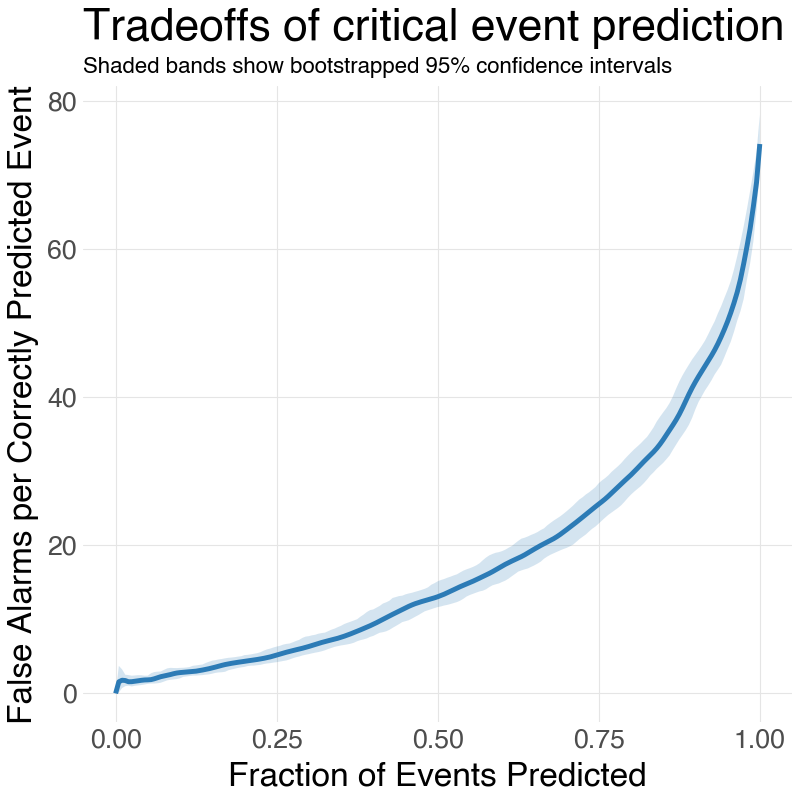

,Sensitivity,estimate,lower_conf,upper_conf
0,0.000,0.000000,0.000000,0.000000
1,0.005,1.566093,0.100965,3.718223
2,0.010,1.780987,0.728608,3.247351
3,0.015,1.738637,0.973759,2.523283
4,0.020,1.573768,1.039905,2.474097
...,...,...,...,...
196,0.980,60.308101,55.836999,65.369571
197,0.985,62.744574,58.059815,67.848219
198,0.990,65.733208,60.998237,70.405042
199,0.995,69.031561,65.200571,73.048406


In [293]:
%matplotlib inline

import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_ribbon, geom_line,
    labs, theme_minimal, theme,
    element_text, element_blank, element_line
)

# Load raw per-bootstrap, per-threshold results (NOT the summarised version —
# we need each bootstrap's individual curve to interpolate correctly).
thresh_results = pd.read_csv(save_filepath + "outputs/thresholds-on-test-set.csv", index_col=0)


def interpolate_metric_pair(df, x_metric, y_metric, x_grid):
    """
    For each bootstrap, sort by x_metric and interpolate y_metric onto a
    common x_grid. Returns a matrix of shape (n_bootstraps, len(x_grid)).
    """
    curves = []
    for idx, g in df.groupby('Index'):
        g = g.sort_values(x_metric)
        x_vals = g[x_metric].values
        y_vals = g[y_metric].values

        valid = ~np.isnan(x_vals) & ~np.isnan(y_vals)
        x_vals, y_vals = x_vals[valid], y_vals[valid]

        # np.interp requires x_vals ascending and unique-ish; sort handles ascending.
        # Where x_metric has duplicate values (flat regions), interp just uses the
        # first match in sorted order, which is fine for monotonic-ish metrics.
        y_interp = np.interp(x_grid, x_vals, y_vals)
        curves.append(y_interp)

    return np.array(curves)  # shape (n_bootstraps, len(x_grid))


def plot_metrics_interpolated(x, y, title, x_name=None, y_name=None,
                               x_grid=None, n_grid=201, fill='#2c7bb6', color='#2c7bb6'):

    if x_grid is None:
        x_grid = np.linspace(0, 1, n_grid)

    y_matrix = interpolate_metric_pair(thresh_results, x, y, x_grid)

    plot_df = pd.DataFrame({
        x: x_grid,
        'estimate': np.nanmean(y_matrix, axis=0),
        'lower_conf': np.nanpercentile(y_matrix, 2.5, axis=0),
        'upper_conf': np.nanpercentile(y_matrix, 97.5, axis=0)
    })

    p = (
        ggplot(plot_df, aes(x=x, y='estimate', ymin='lower_conf', ymax='upper_conf'))
        + geom_ribbon(alpha=0.2, fill=fill)
        + geom_line(size=1, color=color)
        + labs(
            title=title,
            subtitle='Shaded bands show bootstrapped 95% confidence intervals',
            x=x if x_name is None else x_name,
            y=y if y_name is None else y_name
        )
        + theme_minimal(base_size=12)
        + theme(
            figure_size=(4, 4),
            plot_title=element_text(size=16, weight='bold'),
            plot_subtitle=element_text(size=8),
            panel_grid_minor=element_blank(),
            panel_grid_major=element_line(size=0.4),
            axis_title=element_text(size=12, weight='bold'),
        )
    )

    p.show()
    return plot_df


plot_metrics_interpolated(
    'Sensitivity', 'False Discovery Ratio',
    'Tradeoffs of critical event prediction',
    x_name='Fraction of Events Predicted',
    y_name='False Alarms per Correctly Predicted Event'
)

If we look at all the patients who arrived on a given day, just from their ESI distributions + admission rates, can we predict how many of them will be in the ED longer than 8 hours?

In [320]:
#Load data.
raw_visits = pd.read_csv(load_filepath + raw_file_name + ".csv", index_col=0, low_memory=False)
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)

#We are interested in everything we know about the patient at triage, plus:
current_diagnoses = ['current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                  'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                    'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                    'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                    'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                    'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                    'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                    'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders']

#Actual outcomes.
outcomes = ['is_admitted']

#Get ED LOS.
dispositions = pd.read_csv(raw_filepath + "LaCava_Dispositions_Aug7.csv", engine='pyarrow')

#Derive linkage.
linkage = pd.read_csv(raw_filepath + "LaCava_Demopgraphics_May1_V1.csv", engine='pyarrow')[['CSN', 'MRN', 'DOB', 'NAME', 'ED_ARRIVAL_TIME']].drop_duplicates()


#Attach CSNs to disposition tables.
dispositions = dispositions.rename(columns={'ED_CHECKIN_DT_TM':'ED_ARRIVAL_TIME'}).merge(
    linkage[['CSN', 'NAME', 'DOB', 'ED_ARRIVAL_TIME']], on=['NAME', 'DOB', 'ED_ARRIVAL_TIME'], how='inner').rename(
        columns={'CSN':'csn'}
    )


#Order by checkout time and take the first checkout time to be the controlling one.
dispositions['ED_CHECKOUT_DT_TM'] = pd.to_datetime(dispositions['ED_CHECKOUT_DT_TM'])
dispositions = dispositions.sort_values('ED_CHECKOUT_DT_TM')
dispositions = dispositions.drop_duplicates(subset=['csn', 'ED_ARRIVAL_TIME'])
dispositions['ed_los'] = (
    pd.to_datetime(dispositions['ED_CHECKOUT_DT_TM']) - pd.to_datetime(dispositions['ED_ARRIVAL_TIME'])
).dt.total_seconds() / 60



#Attach all of these.
visits = visits.merge(raw_visits[['csn']+current_diagnoses], on='csn', how='inner')


#Check
assert(len(visits) == len(visits['csn'].unique()))

visits = visits.merge(dispositions[['csn', 'ed_los', 'ED_ARRIVAL_TIME']], on='csn', how='left')

#Assign day-number to all pf these.
visits['day_number'] = (visits['ED_ARRIVAL_TIME'].dt.normalize() - visits['ED_ARRIVAL_TIME'].dt.normalize().min()).dt.days + 1 #Normalise strips all dates to midnight.

assert(len(visits) == len(visits['csn'].unique()))
visits.to_csv(save_filepath+'intermediate-files/visits-with-ed-los-and-diagnoses.csv')


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_31183/4238957985.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


In [342]:
#Load visits with this information.
visits = pd.read_csv(save_filepath+'intermediate-files/visits-with-ed-los-and-diagnoses.csv', index_col=0)
visits['ED_ARRIVAL_TIME'] = pd.to_datetime(visits['ED_ARRIVAL_TIME'])


#Extract day, month and year of arrival
visits['arrival_date'] = visits['ED_ARRIVAL_TIME'].dt.day.astype(str) + '-' + visits['ED_ARRIVAL_TIME'].dt.month.astype(str) + '-' + visits['ED_ARRIVAL_TIME'].dt.year.astype(str)


#Get aggregate statistics for each date.

#---PREDICTION BASIS----
#Number of visits/admissions in each triage level:
burden = visits.groupby(['arrival_date', 'triage_acuity']).agg(
    num_visits = ('csn', 'size'),
    num_admissions = ('is_admitted', 'sum')
).reset_index()


#----OUTCOMES-----
#Length of stay for each visit and admission:
los_outcomes = visits.groupby(['arrival_date', 'is_admitted']).agg(
    ed_los = ('ed_los', 'median')
).reset_index()

#Fraction of patients with ED LOS > 8 hours.
visits['prolonged_los'] = (visits['ed_los'] > 60*8).astype(int)
prolonged_los = visits.groupby(['arrival_date']).agg(
    long_stay_rate = ('prolonged_los', 'mean'),
    long_stay = ('prolonged_los', 'mean')
).reset_index()


#----MELT AND JOIN THESE TOGETHER------
burden['triage_acuity'] = burden['triage_acuity'].astype(int)
burden = burden.pivot_table(
    index=['arrival_date'],
    columns=['triage_acuity'],
    values=['num_visits', 'num_admissions']
).reset_index()

# Flatten the MultiIndex columns into single strings
burden.columns = [
    '_'.join(str(level) for level in col if level not in ('', None)).rstrip('_')
    for col in burden.columns
]

#All NaNs in this context are 0.
burden = burden.fillna(0)

los_outcomes = los_outcomes.pivot_table(
    index='arrival_date',
    columns=['is_admitted'],
    values='ed_los'
).reset_index()

los_outcomes = los_outcomes.rename(columns={
    0: 'time_to_discharge',
    1: 'time_to_admission'
})
los_outcomes.columns.name = None


#Link weekday, month and year.
arrival_dates = visits[['csn', 'arrival_date', 'ED_ARRIVAL_TIME']].drop_duplicates()
arrival_dates['wday'] = visits['ED_ARRIVAL_TIME'].dt.weekday
arrival_dates['month'] = visits['ED_ARRIVAL_TIME'].dt.month
arrival_dates['year'] = visits['ED_ARRIVAL_TIME'].dt.year


print(len(burden))

burden = burden.merge(
    los_outcomes, on='arrival_date', how='inner'
)
print(len(burden))

burden = burden.merge(
    prolonged_los, on='arrival_date', how='inner')

print(len(burden))

burden = burden.merge(
    arrival_dates[['arrival_date', 'wday', 'month', 'year']].drop_duplicates(), on='arrival_date', how='inner'
)
print(len(burden))


#----SAVE THESE-----
burden.to_csv(save_filepath+'intermediate-files/daily-burden-stats.csv')


###----SPLIT AGGREGATE DATA-------
#Load split to work out how to split dates.
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath+"outputs/split.joblib")
train_dates, test_dates = arrival_dates.merge(csn_train, on='csn', how='inner')[['arrival_date']].drop_duplicates(), arrival_dates.merge(csn_test, on='csn', how='inner')[['arrival_date']].drop_duplicates() #Get training visits.
train_burden, test_burden = burden.merge(train_dates, on='arrival_date', how='inner'), burden.merge(test_dates, on='arrival_date', how='inner')



train_burden.to_csv(save_filepath+'intermediate-files/daily-burden-stats-train.csv')
test_burden.to_csv(save_filepath+'intermediate-files/daily-burden-stats-test.csv')



/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_31183/3361931066.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


1978
1978
1978
1978


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=2, min_child_weight=1, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=2, min_child_weight=1, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.85, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=2, min_child_weight=1, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=2, min_child_weight=1, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.85, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=2, min_child_weight=1, n_estimators=200, subsample=0.7; tot

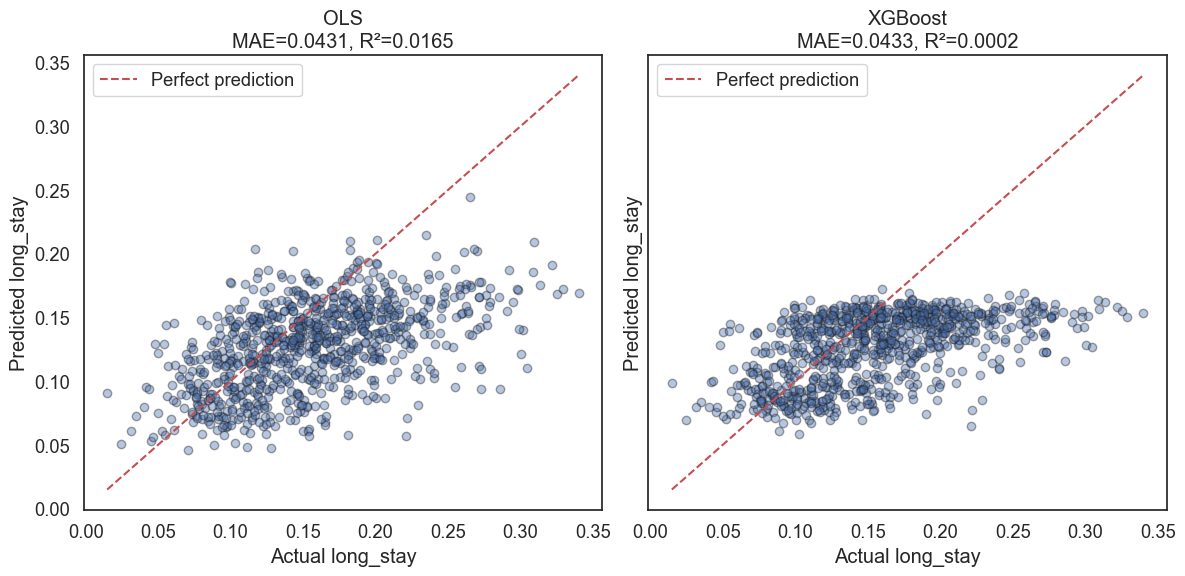

In [344]:
#Load these data.
train_burden = pd.read_csv(save_filepath+'intermediate-files/daily-burden-stats-train.csv', index_col=0)
test_burden = pd.read_csv(save_filepath+'intermediate-files/daily-burden-stats-test.csv', index_col=0)


burden_predictors = ['num_admissions_1', 'num_admissions_2', 'num_admissions_3', 'num_admissions_4',
                      'num_admissions_5', 'num_visits_1', 'num_visits_2', 'num_visits_3', 'num_visits_4', 
                      'num_visits_5', 'wday', 'month', 'year']
burden_outcomes = ['time_to_discharge', 'time_to_admission', 'long_stay']


import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ---- Build one-hot encoded feature set ----
categorical_cols = ['wday', 'month', 'year']
numeric_cols = [c for c in burden_predictors if c not in categorical_cols]

def encode_features(df):
    num = df[numeric_cols]
    cat = pd.get_dummies(df[categorical_cols].astype('category'), drop_first=True)
    return pd.concat([num, cat], axis=1)

X_train_full = encode_features(train_burden)
X_test_full = encode_features(test_burden)

# Align columns in case test set is missing a category level seen in train (or vice versa)
X_train_full, X_test_full = X_train_full.align(X_test_full, join='left', axis=1, fill_value=0)

# ---- Hyperparameter search space for XGBoost ----
xgb_param_dist = {
    'n_estimators': [100, 200, 400],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5]
}


results = []
predictions = []
fitted_models = {}

for outcome in burden_outcomes:
    y_train = train_burden[outcome]
    y_test = test_burden[outcome]

    train_mask = y_train.notna()
    test_mask = y_test.notna()

    X_train_o, y_train_o, dates_train = X_train_full[train_mask], y_train[train_mask], train_burden[train_mask]['arrival_date']
    X_test_o, y_test_o, dates_test = X_test_full[test_mask], y_test[test_mask], test_burden[test_mask]['arrival_date']

    # --- OLS ---
    ols = LinearRegression()
    ols.fit(X_train_o, y_train_o)
    ols_preds = ols.predict(X_test_o)

    # --- XGBoost with randomized hyperparameter search ---
    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=RANDOM_STATE),
        param_distributions=xgb_param_dist,
        n_iter=50,
        scoring='neg_mean_absolute_error',
        cv=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2
    )
    xgb_search.fit(X_train_o, y_train_o)
    best_xgb = xgb_search.best_estimator_
    xgb_preds = best_xgb.predict(X_test_o)

    for model_name, model, preds in [
        ('OLS', ols, ols_preds),
        ('XGBoost', best_xgb, xgb_preds)
    ]:
        predictions += [pd.DataFrame({
            'arrival_date':dates_test,
            'y_true':y_test_o,
            'y_pred':preds,
        }).assign(Outcome=outcome, Model=model_name)]
        fitted_models[(outcome, model_name)] = model

        results.append({
            'outcome': outcome,
            'model': model_name,
            'n_test': len(y_test_o),
            'MAE': mean_absolute_error(y_test_o, preds),
            'RMSE': np.sqrt(mean_squared_error(y_test_o, preds)),
            'R2': r2_score(y_test_o, preds),
            'best_params': xgb_search.best_params_ if model_name == 'XGBoost' else None
        })

results_df = pd.DataFrame(results).sort_values(['outcome', 'model']).reset_index(drop=True)
predictions = pd.concat(predictions, ignore_index=True)
results_df.to_csv(save_filepath+'outputs/aggregate-outcome-prediction-metrics.csv')
predictions.to_csv(save_filepath+'outputs/aggregate-outcome-prediction.csv')

results_df

long_stay_preds = predictions[predictions['Outcome'] == 'long_stay']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, model_name in zip(axes, ['OLS', 'XGBoost']):
    subset = long_stay_preds[long_stay_preds['Model'] == model_name]
    mae = mean_absolute_error(subset['y_true'], subset['y_pred'])
    r2 = r2_score(subset['y_true'], subset['y_pred'])

    ax.scatter(subset['y_true'], subset['y_pred'], alpha=0.4, edgecolor='k')
    lims = [
        min(subset['y_true'].min(), subset['y_pred'].min()),
        max(subset['y_true'].max(), subset['y_pred'].max())
    ]
    ax.plot(lims, lims, 'r--', label='Perfect prediction')
    ax.set_xlabel('Actual long_stay')
    ax.set_ylabel('Predicted long_stay')
    ax.set_title(f'{model_name}\nMAE={mae:.4f}, R²={r2:.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig(save_filepath + 'outputs/long_stay_predicted_vs_actual.png', dpi=150)
plt.show()



OK, aggregate performance is quite bad. Let's try individual performance. Can we predict whether patients are going to have an ED LOS greater than 8 hours or not? Use their own triage presentation, their eventual diagnosis, whether or not they were admitted, and how many people were admitted/discharged in different acuity levels on that day. 

In [323]:
#Load data.
visits = pd.read_csv(save_filepath+'intermediate-files/visits-with-ed-los-and-diagnoses.csv', index_col=0)

#Get aggregate statistics about triage severity and admissions on that day.
burden = visits.groupby(['day_number', 'triage_acuity']).agg(
    num_visits = ('csn', 'size'),
    num_admissions = ('is_admitted', 'sum')
).reset_index()

#----MELT AND JOIN THESE TOGETHER------
burden['triage_acuity'] = burden['triage_acuity'].astype(int)
burden = burden.pivot_table(
    index=['day_number'],
    columns=['triage_acuity'],
    values=['num_visits', 'num_admissions']
).reset_index()

# Flatten the MultiIndex columns into single strings
burden.columns = [
    '_'.join(str(level) for level in col if level not in ('', None)).rstrip('_')
    for col in burden.columns
]

#All NaNs in this context are 0.
burden = burden.fillna(0)

#Add these to visits.
visits = visits.merge(burden, on='day_number', how='inner')
visits['prolonged_stay'] = (visits['ed_los'] >= 60*8).astype(int)


#Now split into test and train.
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath+"outputs/split.joblib")
train_df, test_df = visits.merge(csn_train, on='csn', how='inner'), visits.merge(csn_test, on='csn', how='inner')
train_df.to_csv(save_filepath+'intermediate-files/train-los-predictors.csv')
test_df.to_csv(save_filepath+'intermediate-files/test-los-predictors.csv')


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_31183/526029632.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


In [329]:

#Define predictors.
pre_binarised_predictors_for_los_prediction = ['is_admitted',
                                               'is_trans_or_nb', 'is_weekend', 'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 
                                               'pre_diagnosis_nausea_and_vomiting', 'pre_diagnosis_diabetes_mellitus', 
                                               'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular', 
                                               'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 
                                               'pre_diagnosis_anemia', 'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 
                                               'pre_diagnosis_chromosomal_anomalies', 'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 
                                               'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse', 'pre_diagnosis_smoking', 'pre_diagnosis_depression', 
                                               'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 'pre_diagnosis_sleep_disorders', 
                                               'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 'complaint_contains_abdominal_pain', 
                                               'complaint_contains_assault', 'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status', 
                                               'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 'complaint_contains_burn', 
                                               'complaint_contains_cardiac', 'complaint_contains_chest_pain', 'complaint_contains_chronic_disease', 
                                               'complaint_contains_congestion', 'complaint_contains_constipation', 'complaint_contains_cough', 
                                               'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                                               'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint', 
                                               'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                               'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                               'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed', 
                                               'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                               'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                               'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                               'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy',
                                                 'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                                 'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat', 
                                                 'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                                                 'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                                                 'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety', 
                                                 'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting', 
                                                 'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                                                 'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                                                 'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 
                                                 'current_diagnosis_eating_disorders', 'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 
                                                 'current_diagnosis_chromosomal_anomalies', 'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 
                                                 'current_diagnosis_sleep_disorders', 'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 
                                                 'current_diagnosis_joint_disorders']

categorical_predictors_for_los_prediction = ['race', 'sex', 'ed_arrival_mode', 'language', 'insurance', 
                                             'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']

continuous_predictors_for_los_prediction = ['age_in_days', 'miles_travelled', 'sdi_score', 'raw_triage_hr', 
                                            'raw_triage_rr', 'raw_triage_sp_o2', 'raw_triage_pain', 'raw_triage_sbp', 'raw_triage_dbp', 'crowdedness', 'raw_weight',
                                            'num_admissions_1', 'num_admissions_2', 'num_admissions_3', 'num_admissions_4', 'num_admissions_5',
                                              'num_visits_1', 'num_visits_2', 'num_visits_3', 'num_visits_4', 'num_visits_5']

# ============================== CONFIG ===================================
train_df, test_df = (
    pd.read_csv(save_filepath + 'intermediate-files/train-los-predictors.csv', index_col=0),
    pd.read_csv(save_filepath + 'intermediate-files/test-los-predictors.csv', index_col=0)
)

categorical_predictors = categorical_predictors_for_los_prediction
pre_binarised_predictors = pre_binarised_predictors_for_los_prediction
continuous_predictors = continuous_predictors_for_los_prediction

predictor_cols = categorical_predictors + pre_binarised_predictors + continuous_predictors
outcome_col = 'prolonged_stay'
# ===========================================================================


def fill_unknown(df):
    """
    Treat missing categorical values as their own explicit category,
    'unknown', rather than as NaN.
    """
    df = df.copy()
    for c in categorical_predictors:
        df[c] = df[c].astype(str).where(df[c].notna(), "unknown")
        df[c] = df[c].replace({"nan": "unknown", "None": "unknown"})
    return df


def build_preprocessor():
    """
    One-hot encode categoricals for RF / XGBoost.
    Continuous + binary columns pass through unchanged (trees don't need scaling).

    handle_unknown="ignore" (rather than "error") since train/test are pre-split
    externally here -- if test contains a category level absent from train
    (e.g. a rare 'home_state' or 'insurance' value), we don't want a hard crash;
    unseen levels just get all-zero dummy columns.
    """
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_predictors),
        ],
        remainder="passthrough",
    )


def prepare_data(train_df, test_df):
    """
    Fill unknowns, then fit the one-hot encoder on TRAIN ONLY and apply
    the same fitted transform to test -- avoids leaking test category
    levels into the encoding and keeps train/test columns aligned.
    """
    train_df = fill_unknown(train_df)
    test_df = fill_unknown(test_df)

    preprocessor = build_preprocessor()
    X_train = preprocessor.fit_transform(train_df[predictor_cols])
    X_test = preprocessor.transform(test_df[predictor_cols])

    if not isinstance(X_train, pd.DataFrame):
        X_train = pd.DataFrame(X_train, index=train_df.index)
        X_test = pd.DataFrame(X_test, index=test_df.index)

    y_train = train_df[outcome_col].copy()
    y_test = test_df[outcome_col].copy()

    csn_train = train_df['csn'].copy() if 'csn' in train_df.columns else None
    csn_test = test_df['csn'].copy() if 'csn' in test_df.columns else None

    print("training dataset")
    print(y_train.value_counts())
    print("test dataset")
    print(y_test.value_counts())

    return X_train, X_test, y_train, y_test, csn_train, csn_test




def run_presplit_pipeline(train_df, test_df):

    print("Preprocessing data...")
    X_train, X_test, y_train, y_test, csn_train, csn_test = prepare_data(train_df, test_df)

    results = []

    # ---------------- XGBoost (needs one-hot encoding) ---------------------
    xgb_pipe = Pipeline([
        ("model", XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    xgb_param_dist = {
        "model__n_estimators": randint(200, 800),
        "model__max_depth": randint(2, 10),
        "model__learning_rate": uniform(0.01, 0.29),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
        "model__min_child_weight": randint(1, 10),
        "model__gamma": uniform(0, 5),
    }
    print("Fitting XGB...")
    xgb_best = search_and_report(
        "XGBoost", xgb_pipe, xgb_param_dist, X_train, y_train
    )
    results.append(evaluate("XGBoost", xgb_best, X_test, y_test))

    return results, (X_train, X_test, y_train, y_test, csn_train, csn_test)


results, (X_train, X_test, y_train, y_test, csn_train, csn_test) = run_presplit_pipeline(train_df, test_df)


#We are interested primarily in predicted probabilities here, so attach these.
prediction = pd.DataFrame({
    'csn':csn_test,
    'y_true':y_test.astype(int),
    'y_proba':results[0]['y_proba']
}).reset_index()

#Save these.
prediction.to_csv(save_filepath + "outputs/test-preds-prolonged-stay.csv")

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_31183/1475858241.py:50: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Preprocessing data...
training dataset
prolonged_stay
0    95295
1    10290
Name: count, dtype: int64
test dataset
prolonged_stay
0    93414
1    12108
Name: count, dtype: int64
Fitting XGB...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END model__colsample_bytree=0.6146158666205834, model__gamma=3.942994624747906, model__learning_rate=0.17398834891164855, model__max_depth=8, model__min_child_weight=5, model__n_estimators=242, model__subsample=0.9828258329977864; total time=   3.2s
[CV] END model__colsample_bytree=0.6265448315514909, model__gamma=4.301864057445269, model__learning_rate=0.09200884334807977, model__max_depth=4, model__min_child_weight=7, model__n_estimators=297, model__subsample=0.7874528681015425; total time=   4.0s
[CV] END model__colsample_bytree=0.6265448315514909, model__gamma=4.301864057445269, model__learning_rate=0.09200884334807977, model__max_depth=4, model__min_child_weight=7, model__n_estimators=297, model__subsample=0.7874528681015425

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


[CV] END model__colsample_bytree=0.7205154939892514, model__gamma=1.7358221076559388, model__learning_rate=0.09678497083223409, model__max_depth=6, model__min_child_weight=9, model__n_estimators=235, model__subsample=0.7387301145956398; total time=   4.5s
[CV] END model__colsample_bytree=0.7205154939892514, model__gamma=1.7358221076559388, model__learning_rate=0.09678497083223409, model__max_depth=6, model__min_child_weight=9, model__n_estimators=235, model__subsample=0.7387301145956398; total time=   4.4s
[CV] END model__colsample_bytree=0.7205154939892514, model__gamma=1.7358221076559388, model__learning_rate=0.09678497083223409, model__max_depth=6, model__min_child_weight=9, model__n_estimators=235, model__subsample=0.7387301145956398; total time=   4.5s
[CV] END model__colsample_bytree=0.7205154939892514, model__gamma=1.7358221076559388, model__learning_rate=0.09678497083223409, model__max_depth=6, model__min_child_weight=9, model__n_estimators=235, model__subsample=0.7387301145956

I am probably overcomplicating this.

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_31183/884378427.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


                 Generalized Linear Model Regression Results                  
Dep. Variable:        prolonged_stays   No. Observations:                 1978
Model:                            GLM   Df Residuals:                     1974
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7716.6
Date:                Tue, 25 Aug 2026   Deviance:                       5921.8
Time:                        16:42:05   Pearson chi2:                 6.04e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9452
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
urgent_visits         0.0342      0.00

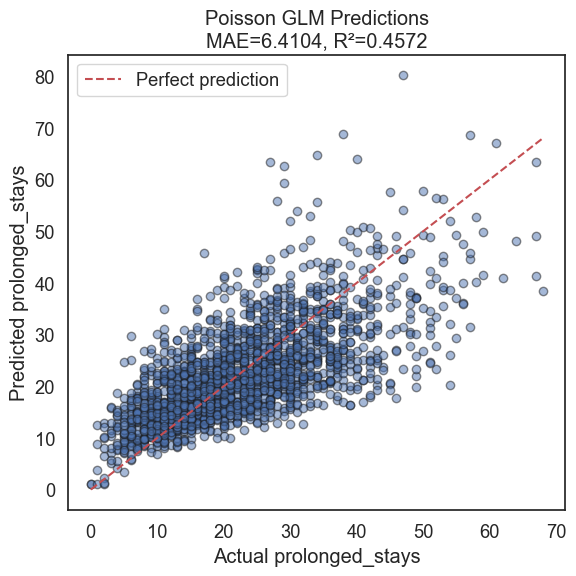

In [341]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score


#Load visits with this information.
visits = pd.read_csv(save_filepath+'intermediate-files/visits-with-ed-los-and-diagnoses.csv', index_col=0)
visits['prolonged_stay'] = (visits['ed_los'] >= 60*8).astype(int)

#Let's focus on exactly three per-day quantities-- number of urgent and non-urgent visits, admissions-- and then fraction of people who waited longer than 8 hours.
aggregate_stats = visits.groupby(['day_number']).agg(
    urgent_visits = ('triage_acuity', lambda y: np.sum(y <= 2)),
    non_urgent_visits = ('triage_acuity', lambda y: np.sum(y > 2)),
    num_admissions = ('is_admitted', 'sum'),
    adm_rate = ('is_admitted', 'mean'),
    prolonged_stays = ('prolonged_stay', 'sum')
).reset_index()
aggregate_stats['total_visits'] = aggregate_stats['non_urgent_visits'] + aggregate_stats['urgent_visits']

predictors = ['urgent_visits', 'non_urgent_visits', 'num_admissions', 'adm_rate']

X = aggregate_stats[predictors]
y = aggregate_stats['prolonged_stays']

poisson_model = sm.GLM(y, X, family=sm.families.Poisson())
poisson_results = poisson_model.fit()
print(poisson_results.summary())

preds = poisson_results.predict(X)

mae = mean_absolute_error(y, preds)
r2 = r2_score(y, preds)
print(f"MAE: {mae:.4f}")
print(f"R2:  {r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y, preds, alpha=0.5, edgecolor='k')
plt.plot([0, y.max()], [0, y.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual prolonged_stays')
plt.ylabel('Predicted prolonged_stays')
plt.title(f'Poisson GLM Predictions\nMAE={mae:.4f}, R²={r2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()
